In [1]:
# Sales Prediction using Random Forest Classifier

Objective:
To predict whether sales will be High or Low using Random Forest Classification
and identify the key factors influencing sales performance.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
# Load Dataset
df = pd.read_csv("D:/Goutham/Projects/Python/Project 5/10. Random Forests/Company_Data.csv")
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [17]:
# Understanding the data
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


(400, 11)

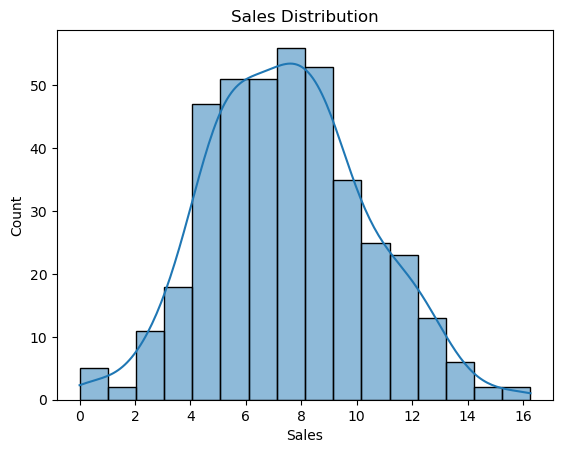

In [5]:
# Exploratory Data Analysis

# Sales Distribution
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

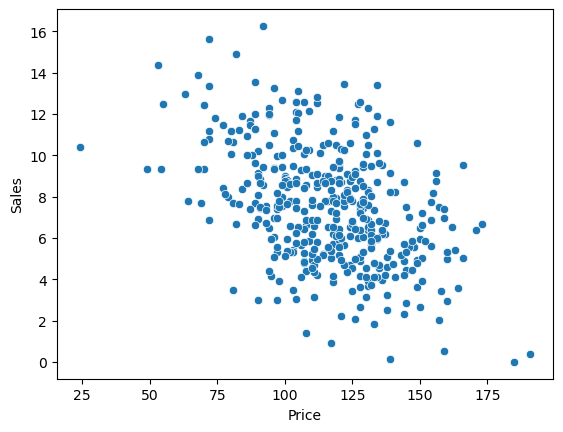

In [6]:
# Sales vs Price
sns.scatterplot(x='Price', y='Sales', data=df)
plt.show()

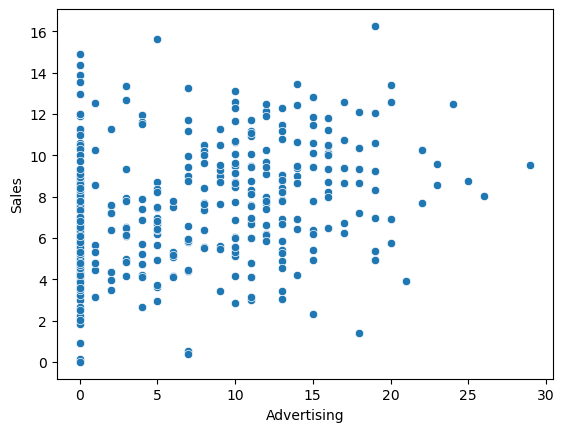

In [7]:
# Sales vs Advertising
sns.scatterplot(x='Advertising', y='Sales', data=df)
plt.show()

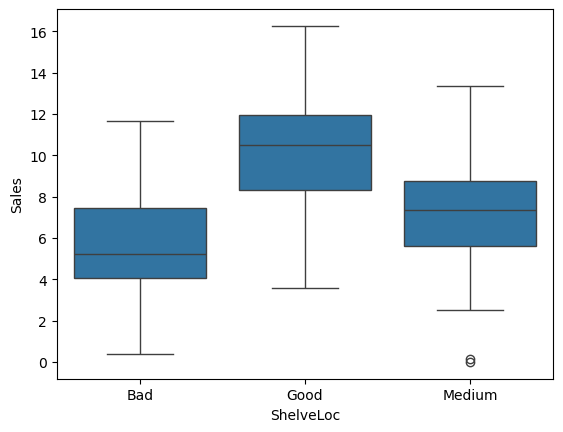

In [8]:
# Shelf location vs Sales
sns.boxplot(x='ShelveLoc', y='Sales', data=df)
plt.show()

Sales tend to increase with better shelf location and higher advertising budgets.

Higher product prices may negatively impact sales.

In [18]:
# Convert Target Variable
df['Sales_Category'] = np.where(df['Sales'] > 8, 1, 0)

In [19]:
# Check Distribution
df['Sales_Category'].value_counts()

Sales_Category
0    236
1    164
Name: count, dtype: int64

Sales were converted into categorical labels:
- High Sales
- Low Sales

This enables classification modeling using Random Forest.

In [20]:
# Drop Original Sales column
df.drop('Sales', axis=1, inplace=True)

In [21]:
# Define X and y
X = df.drop('Sales_Category', axis=1)
y = df['Sales_Category']

In [22]:
# Encoding Categorical variables only in X
X = pd.get_dummies(X, drop_first=True)

In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# Building the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [26]:
# Prediction
y_pred = model.predict(X_test)

In [27]:
# Evaluation

# Accuracy
accuracy_score(y_test, y_pred)

0.75

The Random Forest model achieved an accuracy of 75%.

Given the complexity and variability of real-world business data,
this represents good predictive performance.

The model effectively identifies patterns associated with high and low sales.

In [29]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
4,Price,0.230930
5,Age,0.125443
2,Advertising,0.124528
0,CompPrice,0.104275
7,ShelveLoc_Good,0.102737
1,Income,0.097000
3,Population,0.091353
6,Education,0.056998
8,ShelveLoc_Medium,0.029450
10,US_Yes,0.020258


Feature importance analysis revealed that:

- Price is the most influential factor affecting sales.
- Customer age demographics significantly impact purchasing behavior.
- Advertising expenditure contributes strongly to higher sales.

These insights help the company optimize pricing and marketing strategies.

Business Insights:

1. Product pricing has the strongest impact on sales performance.
2. Advertising investment positively influences high sales.
3. Customer age demographics affect purchasing trends.
4. Better business decisions can be made using feature importance analysis.

Business Recommendations:
- Optimize pricing strategies carefully
- Increase advertising in high-potential markets
- Target customer segments based on age demographics

Random Forest is an ensemble learning algorithm that combines multiple
Decision Trees to improve prediction accuracy and reduce overfitting.

Each tree contributes to the final prediction through majority voting.

Ensemble learning improves model stability by combining predictions
from multiple models instead of relying on a single Decision Tree.

# Final Conclusion:

A Random Forest Classification model was successfully developed
to predict High vs Low sales performance.

EDA and feature importance analysis showed that Price, Age,
and Advertising are the most influential factors affecting sales.

The model achieved good predictive accuracy while reducing overfitting
through ensemble learning.

Business Impact:
- Helps optimize pricing strategies
- Improves advertising decision-making
- Identifies key sales-driving factors
- Supports data-driven business planning

Random Forest provides more stable and reliable predictions
compared to a single Decision Tree model.